Loading audio files...
Audio files loaded successfully.

Signal Length: 4547841

        Pearson Correlation Coefficient
Original vs Instrumental : -0.0895
Original vs Different    : -0.0006
Instrumental vs Different: -0.0015

      Maximum Normalized Cross Correlation
Original vs Instrumental : 0.7649
Original vs Different    : 0.0065
Instrumental vs Different: 0.0071


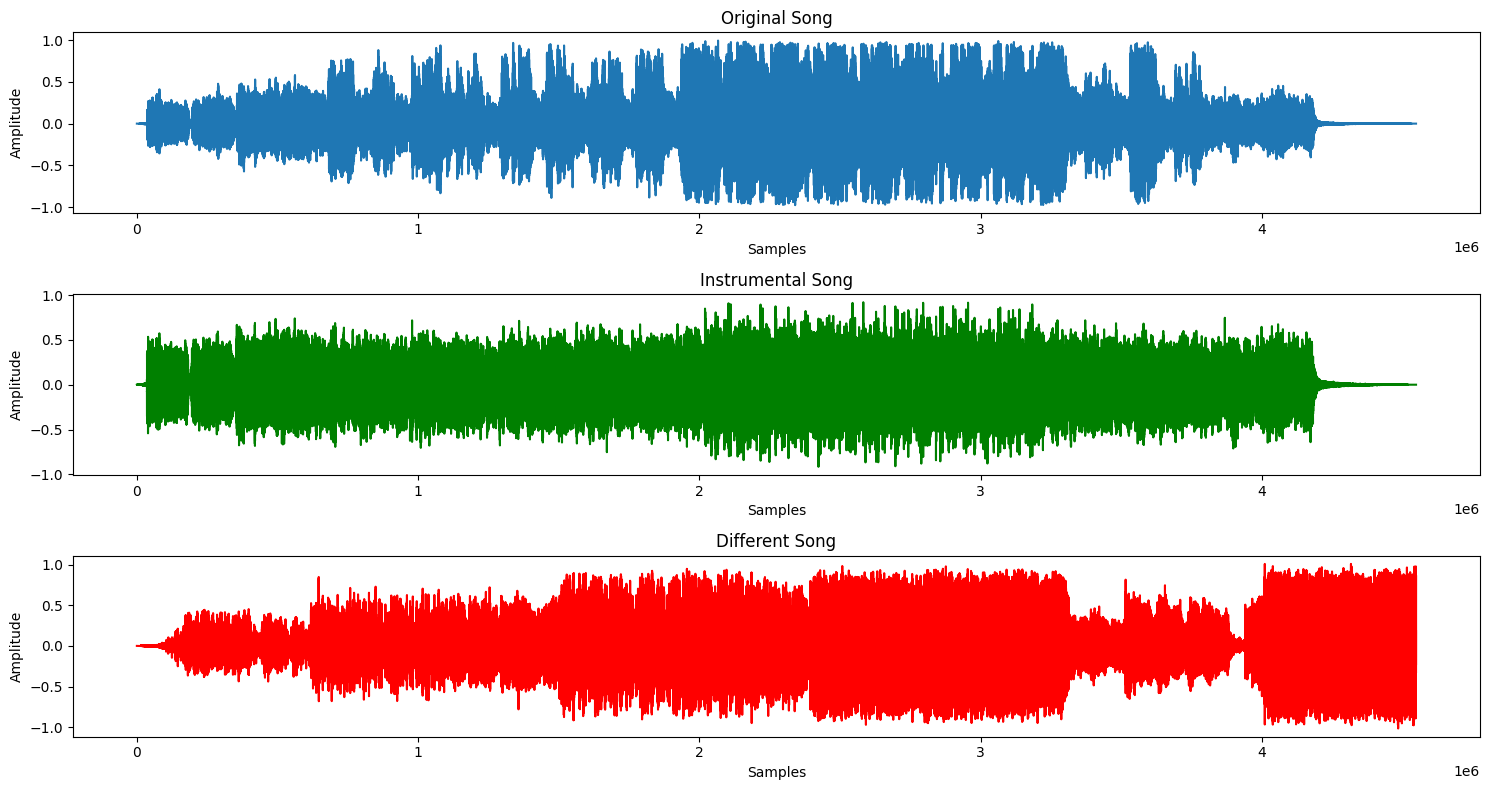

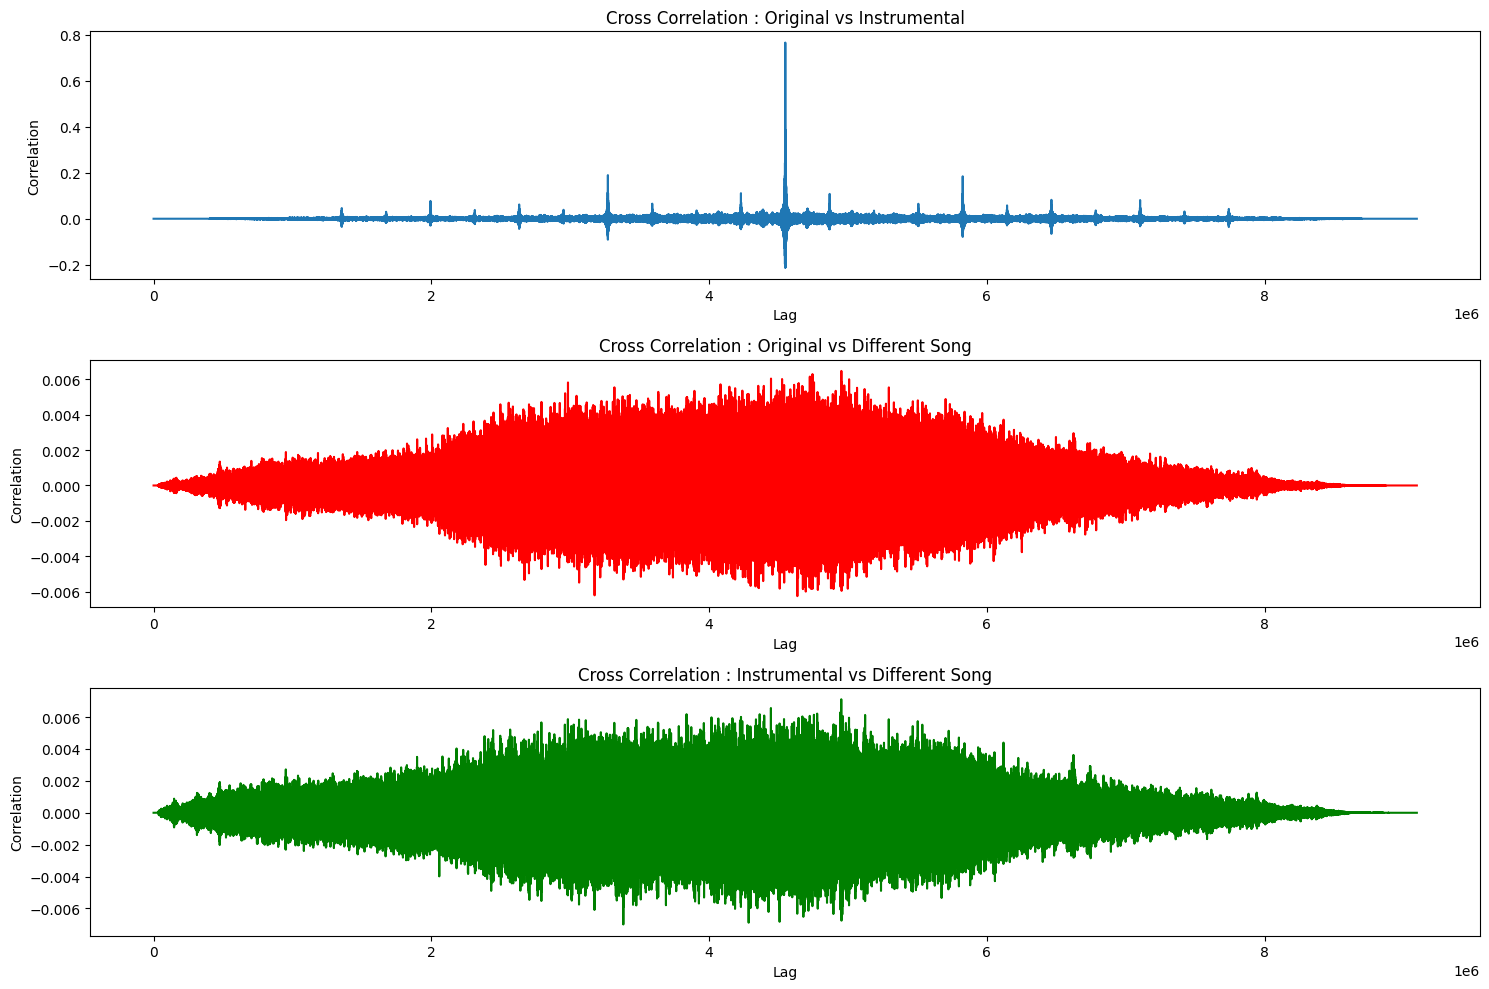

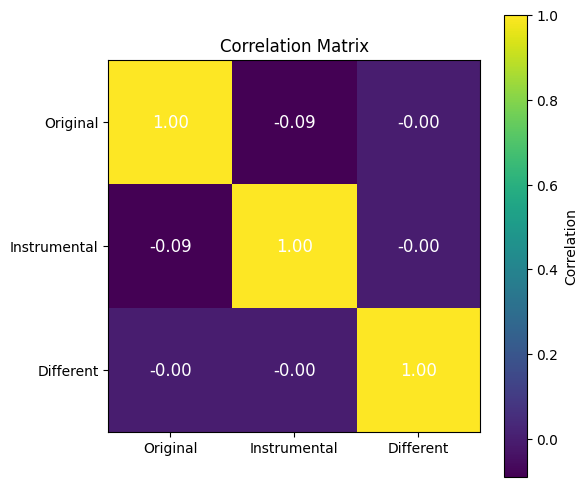

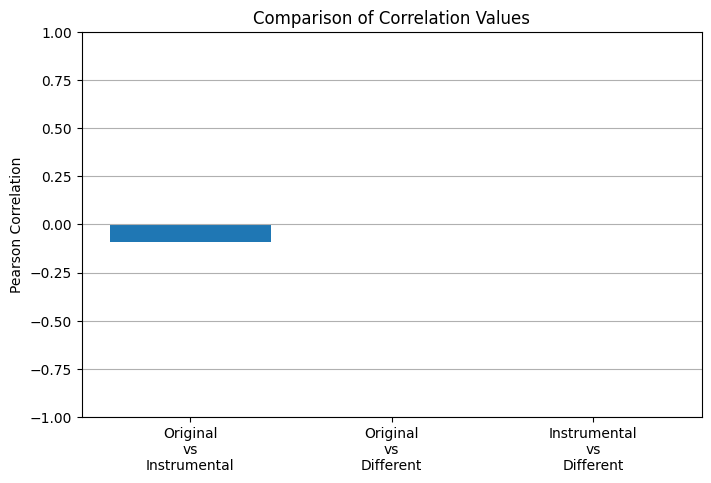


                     CONCLUSION
Correlation values depend on the selected audio files.


In [1]:
# ==========================================================
# Open Ended Problem
# Correlation Analysis of Three Audio Tracks
# ==========================================================

import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.stats import pearsonr

# ----------------------------------------------------------
# Load Audio Files
# ----------------------------------------------------------

print("Loading audio files...")

original, sr = librosa.load("Original.mp3", sr=22050, mono=True)
karaoke, _ = librosa.load("Instrumental.mp3", sr=22050, mono=True)
different, _ = librosa.load("Different.mp3", sr=22050, mono=True)

print("Audio files loaded successfully.")

# ----------------------------------------------------------
# Make All Signals Same Length
# ----------------------------------------------------------

min_length = min(len(original), len(karaoke), len(different))

original = original[:min_length]
karaoke = karaoke[:min_length]
different = different[:min_length]

print("\nSignal Length:", min_length)

# ----------------------------------------------------------
# Pearson Correlation
# ----------------------------------------------------------

corr_ok = pearsonr(original, karaoke)[0]
corr_od = pearsonr(original, different)[0]
corr_kd = pearsonr(karaoke, different)[0]

print("\n" + "="*55)
print("        Pearson Correlation Coefficient")
print("="*55)

print(f"Original vs Instrumental : {corr_ok:.4f}")
print(f"Original vs Different    : {corr_od:.4f}")
print(f"Instrumental vs Different: {corr_kd:.4f}")

# ----------------------------------------------------------
# Normalized Cross Correlation
# ----------------------------------------------------------

def normalized_cross_corr(x, y):

    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)

    corr = correlate(x, y, mode='full')
    corr = corr / len(x)

    return corr

cross_ok = normalized_cross_corr(original, karaoke)
cross_od = normalized_cross_corr(original, different)
cross_kd = normalized_cross_corr(karaoke, different)

print("\n" + "="*55)
print("      Maximum Normalized Cross Correlation")
print("="*55)

print(f"Original vs Instrumental : {np.max(cross_ok):.4f}")
print(f"Original vs Different    : {np.max(cross_od):.4f}")
print(f"Instrumental vs Different: {np.max(cross_kd):.4f}")

# ----------------------------------------------------------
# Plot Audio Signals
# ----------------------------------------------------------

plt.figure(figsize=(15,8))

plt.subplot(3,1,1)
plt.plot(original)
plt.title("Original Song")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3,1,2)
plt.plot(karaoke,color='green')
plt.title("Instrumental Song")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3,1,3)
plt.plot(different,color='red')
plt.title("Different Song")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Plot Cross Correlation
# ----------------------------------------------------------

plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
plt.plot(cross_ok)
plt.title("Cross Correlation : Original vs Instrumental")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.subplot(3,1,2)
plt.plot(cross_od,color='red')
plt.title("Cross Correlation : Original vs Different Song")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.subplot(3,1,3)
plt.plot(cross_kd,color='green')
plt.title("Cross Correlation : Instrumental vs Different Song")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Correlation Matrix
# ----------------------------------------------------------

corr_matrix = np.array([
    [1, corr_ok, corr_od],
    [corr_ok, 1, corr_kd],
    [corr_od, corr_kd, 1]
])

plt.figure(figsize=(6,6))

plt.imshow(corr_matrix, cmap='viridis')

plt.colorbar(label="Correlation")

labels = ["Original","Instrumental","Different"]

plt.xticks(range(3), labels)
plt.yticks(range(3), labels)

plt.title("Correlation Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i,
                 f"{corr_matrix[i,j]:.2f}",
                 ha='center',
                 va='center',
                 color='white',
                 fontsize=12)

plt.show()

# ----------------------------------------------------------
# Bar Graph
# ----------------------------------------------------------

names = [
    "Original\nvs\nInstrumental",
    "Original\nvs\nDifferent",
    "Instrumental\nvs\nDifferent"
]

values = [corr_ok, corr_od, corr_kd]

plt.figure(figsize=(8,5))

plt.bar(names, values)

plt.ylim(-1,1)

plt.ylabel("Pearson Correlation")

plt.title("Comparison of Correlation Values")

plt.grid(axis='y')

plt.show()

# ----------------------------------------------------------
# Final Conclusion
# ----------------------------------------------------------

print("\n" + "="*60)
print("                     CONCLUSION")
print("="*60)

if corr_ok > corr_od and corr_ok > corr_kd:
    print("✓ Original and Instrumental songs are highly similar.")
    print("✓ Different song has very low similarity.")
    print("✓ Correlation analysis successfully distinguishes related and unrelated audio tracks.")
else:
    print("Correlation values depend on the selected audio files.")